## 1. 숫자 필기 데이터 소개
- 사이킷런 패키지에서 제공하는 분류용 예제 데이터로, 0부터 9까지의 숫자를 손으로 쓴 이미지
    - 0부터 15까지의 명암을 가지는 8 × 8 = 64 픽셀 해상도의 흑백 이미지
    - 1,797개의 데이터 포함
- load_digits() 명령으로 로드할 수 있음

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
import torch

digits = load_digits() # 1,797개의 이미지 데이터 로드
print(digits.data.shape) # (1797, 64)
print(digits.images[0]) # (1797,)

(1797, 64)
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


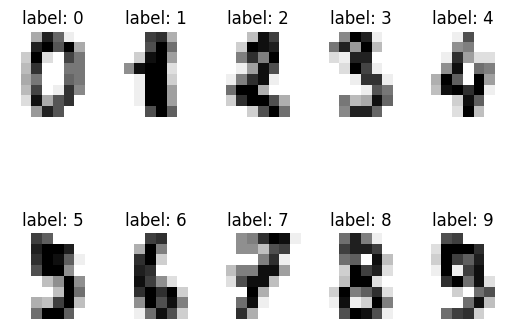

In [2]:
images_and_labels = list(zip(digits.images, digits.target))

for index, (image, label) in enumerate(images_and_labels[:10]): # 5개의 샘플만 출력
    plt.subplot(2, 5, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title(f'label: {label}')

In [3]:
# 데이터셋을 훈련 세트와 테스트 세트로 분리
train_x = torch.tensor(digits.data[0:1600], dtype=torch.float32)
train_y = torch.tensor(digits.target[0:1600], dtype=torch.int64)
test_x = torch.tensor(digits.data[1600:], dtype=torch.float32)
test_y = torch.tensor(digits.target[1600:], dtype=torch.int64)

## 2. 다층 퍼셉트론 분류기 만들기

In [ ]:
import torch.nn as nn
from torch import optim

model = nn.Sequential(
    nn.Linear(64, 128),
    nn.LeakyReLU(),
    nn.Linear(128, 64),
    nn.LeakyReLU(),
    nn.Linear(64, 32),
    nn.LeakyReLU(),
    nn.Linear(32, 10),
)

loss_fn = nn.CrossEntropyLoss() # 이 손실 함수는 Softmax 함수를 포함하고 있음
losses, accuracies = [], []

optimizer = optim.Adam(model.parameters()) # Adam 옵티마이저 사용

In [9]:
for epoch in range(1000):
    optimizer.zero_grad()

    y_pred = model(train_x)
    accuracy = (torch.argmax(y_pred, dim=1) == train_y).float().mean()

    loss = loss_fn(y_pred, train_y)
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 99:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.6f}, Accuracy: {accuracy.item() * 100:.2f}%')

    accuracies.append(((torch.argmax(y_pred, dim=1) == train_y).float().mean()).item())
    losses.append(loss.item())

Epoch 100, Loss: 0.000435, Accuracy: 100.00%
Epoch 200, Loss: 0.000125, Accuracy: 100.00%
Epoch 300, Loss: 0.000053, Accuracy: 100.00%
Epoch 400, Loss: 0.000028, Accuracy: 100.00%
Epoch 500, Loss: 0.000017, Accuracy: 100.00%
Epoch 600, Loss: 0.000011, Accuracy: 100.00%
Epoch 700, Loss: 0.000007, Accuracy: 100.00%
Epoch 800, Loss: 0.000005, Accuracy: 100.00%
Epoch 900, Loss: 0.000004, Accuracy: 100.00%
Epoch 1000, Loss: 0.000003, Accuracy: 100.00%


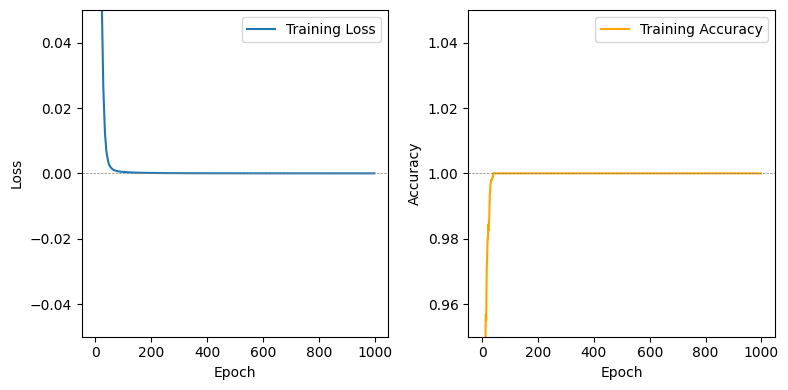

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(losses, label='Training Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_ylim(-0.05, 0.05)
ax[0].axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax[0].legend()

ax[1].plot(accuracies, label='Training Accuracy', color='orange')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim(0.95, 1.05)
ax[1].axhline(1, color='gray', linestyle='--', linewidth=0.5)
ax[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# 모델 평가
with torch.no_grad():
    y_pred = model(test_x)
    predicted_classes = torch.argmax(y_pred, dim=1)
    accuracies = (predicted_classes == test_y).float().mean()
    print(f'Test Accuracy: {accuracies.item() * 100:.2f}%')

Test Accuracy: 92.39%
